In [46]:
!pip install -q transformers pytorchvideo decord

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 56.7 MB/s eta 0:00:00:00:0100:01


In [48]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
import re

In [33]:
TRAIN_VIDEO_DIR = "/kaggle/input/datasets/sluchevskiipersii/video1/train"
TEST_DIR = "/kaggle/input/datasets/sluchevskiipersii/video1/test"

In [34]:
df = pd.read_csv("/kaggle/input/datasets/sluchevskiipersii/video1/train.csv")
print(df.head())
print(f"\ntotal: {len(df)}")

                                                path  labels
0                    port_before_sunrise_preview.mp4  sunset
1  Louisiana speeding boat on Mississippi River_p...   cloud
2                     170509A_Vietnam_03_preview.mp4   water
3  Croatia water on rocks at high tide pan_previe...   water
4        Arizona zoom on sunset mountain_preview.mp4  sunset

total: 290


In [35]:
df['labels'].unique()

array(['sunset', 'cloud', 'water', 'food', 'flower', 'car',
       'cloud. water', 'animal', 'cloud, water', 'dance', 'fire',
       'cloud, sunset', 'water, sunset'], dtype=object)

In [36]:
CLASSES = ['animal', 'car', 'cloud', 'dance', 'fire', 'flower', 'food', 'sunset', 'water']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {i: cls for i, cls in enumerate(CLASSES)}

VIDEO_FRAMES = 16
FRAME_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4

def extract_labels(raw_label):

    if pd.isna(raw_label):
        return []
    
    text = str(raw_label).lower().strip()
    
    text = text.replace("'", "").replace('"', "")
    
    text = re.sub(r'[^a-z]', ' ', text)
    
    candidate_labels = [word for word in text.split() if word in CLASSES]
    
    seen = set()
    unique_labels = []
    for label in candidate_labels:
        if label not in seen:
            seen.add(label)
            unique_labels.append(label)
    
    return unique_labels

df['labels'] = df['labels'].apply(extract_labels)
df['num_labels'] = df['labels'].apply(len)

In [37]:
df

,path,labels,num_labels
0,port_before_sunrise_preview.mp4,[sunset],1
1,Louisiana speeding boat on Mississippi River_p...,[cloud],1
2,170509A_Vietnam_03_preview.mp4,[water],1
3,Croatia water on rocks at high tide pan_previe...,[water],1
4,Arizona zoom on sunset mountain_preview.mp4,[sunset],1
...,...,...,...
285,bees2_preview.mp4,[flower],1
286,170628_016_preview.mp4,[food],1
287,_import_615fd719c295d0.10594294_preview.mp4,[flower],1
288,_import_616e5ebb6151f5.55336006_preview.mp4,[animal],1


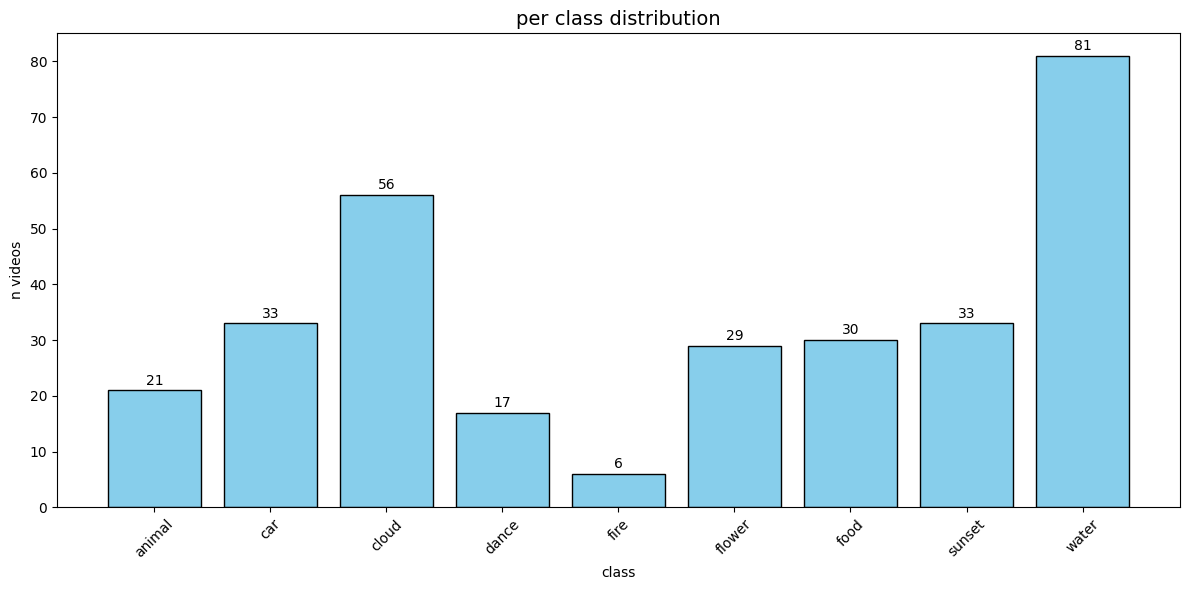

In [38]:
class_counts = {cls: 0 for cls in ['animal', 'car', 'cloud', 'dance', 'fire', 'flower', 'food', 'sunset', 'water']}

for labels in df['labels']:
    for label in labels:
        class_counts[label] += 1

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(12, 6))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title('per class distribution', fontsize=14)
plt.xlabel('class')
plt.ylabel('n videos')
plt.xticks(rotation=45)
for i, v in enumerate(counts):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [39]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class VideoDataset(Dataset):
    def __init__(self, df, video_dir):
        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = f"{self.video_dir}/{row['path']}"
        
        frames = self.extract_frames(video_path)
        frames_tensor = torch.FloatTensor(frames).permute(3, 0, 1, 2)
        
        labels = torch.zeros(NUM_CLASSES)
        for label in row['labels']:
            if label in CLASS_TO_IDX:
                labels[CLASS_TO_IDX[label]] = 1
        
        return frames_tensor, labels
    
    def extract_frames(self, video_path, num_frames=16, size=(224, 224)):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return np.zeros((num_frames, size[0], size[1], 3), dtype=np.float32)
        
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            cap.release()
            return np.zeros((num_frames, size[0], size[1], 3), dtype=np.float32)
        
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        frames = []
        
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, size)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                frames.append(np.zeros((size[0], size[1], 3), dtype=np.uint8))
        
        cap.release()
        return np.array(frames, dtype=np.float32) / 255.0

# class VideoClassifier(nn.Module):
#     def __init__(self, num_classes=9):
#         super().__init__()
#         self.conv1 = nn.Conv3d(3, 64, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm3d(64)
#         self.pool1 = nn.MaxPool3d(kernel_size=2)
        
#         self.conv2 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm3d(128)
#         self.pool2 = nn.MaxPool3d(kernel_size=2)
        
#         self.conv3 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm3d(256)
#         self.pool3 = nn.MaxPool3d(kernel_size=2)
        
#         self.conv4 = nn.Conv3d(256, 512, kernel_size=3, padding=1)
#         self.bn4 = nn.BatchNorm3d(512)
#         self.pool4 = nn.MaxPool3d(kernel_size=2)
        
#         self.adaptive_pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        
#         self.classifier = nn.Sequential(
#             nn.Dropout(0.5),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes),
#             nn.Sigmoid()
#         )
    
#     def forward(self, x):
#         x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
#         x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
#         x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
#         x = self.pool4(torch.relu(self.bn4(self.conv4(x))))
#         x = self.adaptive_pool(x)
#         x = x.view(x.size(0), -1)
#         x = self.classifier(x)
#         return x


class VideoClassifier(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.conv1 = nn.Conv3d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(64)
        self.pool1 = nn.MaxPool3d(kernel_size=2)
        
        self.conv2 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(128)
        self.pool2 = nn.MaxPool3d(kernel_size=2)
        
        self.conv3 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm3d(256)
        self.pool3 = nn.MaxPool3d(kernel_size=2)
        
        self.conv4 = nn.Conv3d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm3d(512)
        self.pool4 = nn.MaxPool3d(kernel_size=2)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 1 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))  # [B,64,8,112,112]
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))  # [B,128,4,56,56]
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))  # [B,256,2,28,28]
        x = self.pool4(torch.relu(self.bn4(self.conv4(x))))  # [B,512,1,14,14]
        
        x = x.view(x.size(0), -1)  # [B, 512*1*14*14]
        x = self.classifier(x)
        return x

In [41]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = VideoDataset(train_df, TRAIN_VIDEO_DIR)
val_dataset = VideoDataset(val_df, TRAIN_VIDEO_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model = VideoClassifier(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

best_val_loss = float('inf')
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for frames, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            outputs = model(frames)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds.append(outputs.cpu().numpy())
            val_targets.append(labels.cpu().numpy())
    
    val_loss /= len(val_loader)
    scheduler.step(val_loss)
    
    val_preds = np.vstack(val_preds)
    val_targets = np.vstack(val_targets)
    pred_binary = (val_preds > 0.5).astype(int)
    
    class_accuracies = []
    for j in range(NUM_CLASSES):
        if val_targets[:, j].sum() > 0:
            acc = (pred_binary[:, j] == val_targets[:, j]).mean()
            class_accuracies.append(acc)
        else:
            class_accuracies.append(0.0)
    
    class_wise_accuracy = np.mean(class_accuracies)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss/len(train_loader):.4f}, Val Loss={val_loss:.4f}, Class-wise Accuracy={class_wise_accuracy:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  Saved best model")

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

Epoch 1/20: 100%|██████████| 29/29 [00:45<00:00,  1.57s/it]


Epoch 1: Train Loss=0.4768, Val Loss=0.4007, Class-wise Accuracy=0.8851
  Saved best model


Epoch 2/20: 100%|██████████| 29/29 [00:45<00:00,  1.57s/it]


Epoch 2: Train Loss=0.3286, Val Loss=0.3192, Class-wise Accuracy=0.8889
  Saved best model


Epoch 3/20: 100%|██████████| 29/29 [00:45<00:00,  1.58s/it]


...

Epoch 8: Train Loss=0.2834, Val Loss=0.3064, Class-wise Accuracy=0.8889


Epoch 9/20: 100%|██████████| 29/29 [00:44<00:00,  1.54s/it]


Epoch 9: Train Loss=0.2745, Val Loss=0.3055, Class-wise Accuracy=0.8851


Epoch 10/20: 100%|██████████| 29/29 [00:43<00:00,  1.51s/it]


KeyboardInterrupt: 

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

val_preds_all = []
val_targets_all = []

with torch.no_grad():
    for frames, labels in tqdm(val_loader, desc="Evaluating"):
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)
        outputs = model(frames)
        probs = outputs.cpu().numpy()
        pred_binary = (probs > 0.5).astype(int)
        
        val_preds_all.append(pred_binary)
        val_targets_all.append(labels.cpu().numpy())

val_preds_all = np.vstack(val_preds_all)
val_targets_all = np.vstack(val_targets_all)


for j, class_name in enumerate(CLASSES):
    true = val_targets_all[:, j]
    pred = val_preds_all[:, j]
    
    tp = ((pred == 1) & (true == 1)).sum()
    tn = ((pred == 0) & (true == 0)).sum()
    fp = ((pred == 1) & (true == 0)).sum()
    fn = ((pred == 0) & (true == 1)).sum()
    
    total = len(true)
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{class_name.upper()}:")
    print(f"  Accuracy:  {accuracy:.4f} ({tp+tn}/{total})")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  TP={tp}, TN={tn}, FP={fp}, FN={fn}")

Evaluating: 100%|██████████| 8/8 [00:10<00:00,  1.33s/it]

ОШИБКИ ПО КАЖДОМУ КЛАССУ

ANIMAL:
  Accuracy:  0.9138 (53/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=53, FP=0, FN=5

CAR:
  Accuracy:  0.8793 (51/58)
  Precision: 0.6667
  Recall:    0.2500
  F1-score:  0.3636
  TP=2, TN=49, FP=1, FN=6

CLOUD:
  Accuracy:  0.8103 (47/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=47, FP=1, FN=10

DANCE:
  Accuracy:  0.9655 (56/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=56, FP=0, FN=2

FIRE:
  Accuracy:  0.9828 (57/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=57, FP=0, FN=1

FLOWER:
  Accuracy:  0.8793 (51/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=51, FP=1, FN=6

FOOD:
  Accuracy:  0.8621 (50/58)
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000
  TP=0, TN=50, FP=0, FN=8

SUNSET:
  Accuracy:  0.8621 (50/58)
  Precision: 0.2500
  Recall:    0.1667
  F1-score:  0.2000
  TP=1, TN=49, FP=3, FN=5

In [42]:
test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.mp4')]
test_df = pd.DataFrame({'path': test_files})

class TestDataset(Dataset):
    def __init__(self, df, video_dir):
        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = os.path.join(self.video_dir, row['path'])
        frames = self.extract_frames(video_path)
        frames_tensor = torch.FloatTensor(frames).permute(3, 0, 1, 2)
        return frames_tensor, row['path']
    
    def extract_frames(self, video_path, num_frames=16, size=(224, 224)):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return np.zeros((num_frames, size[0], size[1], 3), dtype=np.float32)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            cap.release()
            return np.zeros((num_frames, size[0], size[1], 3), dtype=np.float32)
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, size)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                frames.append(np.zeros((size[0], size[1], 3), dtype=np.uint8))
        cap.release()
        return np.array(frames, dtype=np.float32) / 255.0

test_dataset = TestDataset(test_df, TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model = VideoClassifier(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

results = []
with torch.no_grad():
    for frames, paths in tqdm(test_loader, desc="Testing"):
        frames = frames.to(DEVICE)
        outputs = model(frames)
        probs = outputs.cpu().numpy()
        pred_binary = (probs > 0.5).astype(int)
        
        for i, path in enumerate(paths):
            labels = [IDX_TO_CLASS[j] for j, val in enumerate(pred_binary[i]) if val == 1]
            if not labels:
                labels = [CLASSES[np.argmax(probs[i])]]
            results.append({'file_name': path, 'label': ', '.join(labels)})

submission = pd.DataFrame(results)
submission.insert(0, 'index', range(len(submission)))
submission.to_csv('submission.csv', index=False)
print(f"Saved submission.csv with {len(submission)} videos")

Testing: 100%|██████████| 55/55 [01:29<00:00,  1.64s/it]

Saved submission.csv with 435 videos
